# Phase1: The Confustion Matrix and Anatomy of a Mistake

When your trained Logistic Regression model outputs a probability, you use a threshold (usually 0.5) to make a final choice: Is this patient sick (1) or healthy (0)?

Once you make that choice for your whole testing dataset, you compare your predictions against reality. This comparison forms a 2x2 grid called the Confusion Matrix.

## The 4 Quadrants of Reality:
1. True Positive (TP): The patient is actually sick ($y=1$), and your model correctly diagnosed them as sick ($\hat{y}=1$). Success.
2. True Negative (TN): The patient is perfectly healthy ($y=0$), and your model correctly diagnosed them as healthy ($\hat{y}=0$). Success.
3. False Positive (FP) / Type 1 Error: The patient is healthy ($y=0$), but your model set off a false alarm and claimed they are sick ($\hat{y}=1$).
4. False Negative (FN) / Type 2 Error: The patient is actually sick ($y=1$), but your model missed it completely and sent them home with a clean bill of health ($\hat{y}=0$).

## Type 1 vs. Type 2 Errors: Which is deadlier?
In statistics, we call these Type 1 and Type 2 errors. In the real world, they carry radically different consequences depending on what you are predicting.

### The Medical Filter (Predicting Cancer):

- Type 1 (False Alarm): You tell a healthy person they have cancer. They get scared, run a second test, realize they are fine, and breathe a sigh of relief. Cost: Temporary stress and money for a re-test.

- Type 2 (Missed Detection): You tell a person with aggressive cancer that they are perfectly fine. They go home, the disease spreads, and they face catastrophic health outcomes.

- Verdict: In medicine, a Type 2 Error is deadlier. You must minimize False Negatives at all costs.

### The Security Filter (Predicting Spam or Fraud):

- Type 1 (False Alarm): Your email server flags a vital job offer confirmation as "Spam" and hides it. You miss your interview.

- Type 2 (Missed Detection): A junk email offering a fake cruise slips into your inbox. You look at it and hit delete.

- Verdict: In spam filtering, a Type 1 Error is far worse. You want to avoid blocking legitimate communication.

## Metric 1: Accuracy Score
Accuracy is the simplest, most intuitive metric. It answers one straightforward question: "Out of all the guesses my model made, what percentage were completely correct?
"$$\text{Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Predictions}} = \frac{TP + TN}{TP + TN + FP + FN}$$



In [4]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score

# simulated reality: 10 patients  ---- 1 = sick, 0 = healthy
y_true = np.array([1, 0, 1, 1, 0, 0, 1, 0, 1, 0])

# Model Predictions (Logistic Regression outputs)
y_pred = np.array([1, 0, 0, 1, 0, 1, 1, 0, 1, 0])

# crunching the matrix from scratch
def compute_confusion_matrix_scratch(true, pred):
    TP = np.sum((true == 1) & (pred == 1))
    TN = np.sum((true == 0) & (pred == 0))
    FP = np.sum((true == 0) & (pred == 1))
    FN = np.sum((true == 1) & (pred == 0))
    return TN, FP, FN, TP

TN, FP, FN, TP = compute_confusion_matrix_scratch(y_true, y_pred)
accuracy_scratch = (TP + TN) / (TP + TN + FP + FN)

# benchmark against scikit_learn
sk_cm = confusion_matrix(y_true, y_pred)
sk_acc = accuracy_score(y_true, y_pred)

print("--- CUSTOM SCRATCH METRICS ---")
print(f"True Negatives (TN): {TN} | False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN} | True Positives (TP): {TP}")
print(f"Calculated Accuracy: {accuracy_scratch:.2f}")

print("\n--- SCIKIT-LEARN OUTPUT ---")
print("Confusion Matrix Layout [[TN, FP], [FN, TP]]:")
print(sk_cm)
print(f"Sklearn Accuracy: {sk_acc:.2f}")

--- CUSTOM SCRATCH METRICS ---
True Negatives (TN): 4 | False Positives (FP): 1
False Negatives (FN): 1 | True Positives (TP): 4
Calculated Accuracy: 0.80

--- SCIKIT-LEARN OUTPUT ---
Confusion Matrix Layout [[TN, FP], [FN, TP]]:
[[4 1]
 [1 4]]
Sklearn Accuracy: 0.80


# Phase 2: Precision, Recall, and the F1-Score
Accuracy counts raw hits and misses, but it treats all correct answers identically. In production, we need metrics that focus specifically on how our model behaves when it handles the Positive Class ($y=1$).

To do that, we use two targeted lenses: Precison and Recall.

## 1. Precision: The Cost of False Alarms
Precision asks a specific question: "When my model claims a data point is Positive, how often is it actually right?" It isolates the entire Positive Prediction Column ($\hat{y}=1$) and looks at the ratio of true hits to total alarms.

$$\text{Precision} = \frac{\text{True Positives}}{\text{Predicted Positives}} = \frac{TP}{TP + FP}$$

- When do you optimize for Precision? Whenever a False Positive (Type 1 Error) is incredibly costly or damaging.
- Example: A spam filter. If your filter has low precision, it will misclassify your urgent, legitimate emails as spam. You want a precision of 99.9%—if it flags an email as spam, it must be absolutely certain.

## 2. Recall (Sensitivity): The Cost of Missed Detections
Recall asks the opposite question: "Out of all the actual Positive cases in the real world, how many did my model successfully catch?"

It isolates the entire True Positive Row ($y=1$) and checks your coverage percentage.

$$\text{Recall} = \frac{\text{True Positives}}{\text{Actual Positives}} = \frac{TP}{TP + FN}$$

- When do you optimize for Recall? Whenever a False Negative (Type 2 Error) is dangerous or fatal.
- Example: A security system detecting a bank break-in. It doesn't matter if the system sets off a few false alarms due to a stray cat (False Positive). What matters is that if an actual intruder breaks in, the system catches them. You need a recall of 100%.

## 3. The F1-Score: The Balanced Harmonic Mean
You cannot maximize both Precision and Recall simultaneously. If you want a model with 100% Recall, you can just force your model to predict 1 for every single data point. You won't miss a single sick patient (0 False Negatives), but your Precision will plummet because you will unleash a massive wave of false alarms.

To measure the health of a model across both metrics, we use the F1-Score. It is the harmonic mean of Precision and Recall.
$$\text{F1-Score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

### Why a Harmonic Mean instead of a regular average?
A regular arithmetic average can be easily cheated. If a model has a Recall of 1.0 and a Precision of 0.0, a simple average says the model is 50% good: $\frac{1.0 + 0.0}{2} = 0.5$.
The harmonic mean acts like a punishing mechanism. If either metric drops close to zero, the entire F1-Score collapses to zero. It forces the model to maintain a healthy balance between precision and coverage.

In [3]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Same simulated reality of 10 patients
y_true = np.array([1, 0, 1, 1, 0, 0, 1, 0, 1, 0])
y_pred = np.array([1, 0, 0, 1, 0, 1, 1, 0, 1, 0])

# Recalculate basic quadrants from Step 1
TP = np.sum((y_true == 1) & (y_pred == 1))
FP = np.sum((y_true == 0) & (y_pred == 1))
FN = np.sum((y_true == 1) & (y_pred == 0))

# Calculation from scratch
precision_scratch = TP / (TP + FP)
recall_scratch = TP / (TP + FN)
f1_scratch = 2 * (precision_scratch * recall_scratch) / (precision_scratch + recall_scratch)

# benchmark against scikit learn
sk_prec = precision_score(y_true, y_pred)
sk_rec = recall_score(y_true, y_pred)
sk_f1 = f1_score(y_true, y_pred)

print("--- CUSTOM SCRATCH METRICS ---")
print(f"Calculated Precision: {precision_scratch:.4f} (Out of all positive claims, how many were right)")
print(f"Calculated Recall:    {recall_scratch:.4f} (Out of all actual sick cases, how many were caught)")
print(f"Calculated F1-Score:  {f1_scratch:.4f}")

print("\n--- SCIKIT-LEARN OUTPUT ---")
print(f"Sklearn Precision:    {sk_prec:.4f}")
print(f"Sklearn Recall:       {sk_rec:.4f}")
print(f"Sklearn F1-Score:     {sk_f1:.4f}")


--- CUSTOM SCRATCH METRICS ---
Calculated Precision: 0.8000 (Out of all positive claims, how many were right)
Calculated Recall:    0.8000 (Out of all actual sick cases, how many were caught)
Calculated F1-Score:  0.8000

--- SCIKIT-LEARN OUTPUT ---
Sklearn Precision:    0.8000
Sklearn Recall:       0.8000
Sklearn F1-Score:     0.8000


# Phase 3: When Accuracy Lies & The Precision-Recall Tradeoff
Now that you have the mathematical formulas down, we need to look at how these metrics behave under real-world pressure. This is where junior data scientists get caught off guard by a phenomenon called Class Imbalance.

## 1. The Illusion of 99% Accuracy
Imagine you are building a model to detect credit card fraud. Credit card fraud is incredibly rare—out of every 10,000 transactions, only 100 are actually fraudulent ($y=1$), and 9,900 are completely legitimate ($y=0$).

A lazy developer writes a completely broken model that contains a single line of hardcoded logic: Predict 0 for every single transaction.

Let’s check the accuracy score of this completely useless model:
- True Positives (TP): $0$ (It didn't catch a single fraudster).
- True Negatives (TN): $9,900$ (It correctly guessed all legitimate transactions).
- False Positives (FP): $0$.
- False Negatives (FN): $100$ (It missed every single instance of fraud).

$$\text{Accuracy} = \frac{0 + 9900}{10000} = \mathbf{99\%}$$

The manager sees "99% Accuracy" on a dashboard and celebrates. But in reality, the company is losing millions of dollars because the model is entirely blind to fraud.

### How Precision and Recall expose the lie:
If we run this exact same scenario through our business metrics:
- $$\text{Precision} = \frac{0}{0 + 0} = \mathbf{Undefined/0}$$
- $$\text{Recall} = \frac{0}{0 + 100} = \mathbf{0\%}$$
- $$\text{F1-Score} = \mathbf{0}$$

The moment you look at the F1-Score, the illusion is shattered. Accuracy lies when your classes are imbalanced because it allows the massive majority class to hide the catastrophic failures of the minority class.

## 2. The Precision-Recall Tradeoff
How does a Logistic Regression model actually decide if a transaction is a 1 or a 0? It calculates a probability (e.g., 0.65) and checks it against a Classification Threshold (typically 0.5).

If $\hat{y} \ge \text{Threshold}$, classify as 1.
If $\hat{y} < \text{Threshold}$, classify as 0.

You can manually move this threshold slider up or down to alter your model's behavior depending on your risk tolerance.

### Shifting the Slider:

**Scenario A: Shifting the Threshold UP (to 0.9)**
You tell the model: "Only flag fraud if you are 90% absolutely certain."
* The Result: The model becomes highly conservative. False alarms drop to nearly zero ($\text{FP} \to 0$). Your Precision skyrockets. However, because the filter is so strict, you miss dozens of clever fraudsters who scored a 0.85. Your Recall plummets.

**Scenario B: Shifting the Threshold DOWN (to 0.1)**
You tell the model: "If there is even a 10% suspicion of fraud, lock the card down!"
* The Result: The model catches every single trace of fraud ($\text{FN} \to 0$). Your Recall hits 100%. However, your phone system melts down because thousands of innocent customers have their cards declined at grocery stores ($\text{FP}$ explodes). Your Precision plummets.

--- THE ACCURACY TRAP (DUMMY MODEL) ---
Dummy Accuracy:  0.9440 <-- Looks perfect!
Dummy Precision: 0.0000
Dummy Recall:    0.0000
Dummy F1-Score:  0.0000 <-- Exposes the truth.


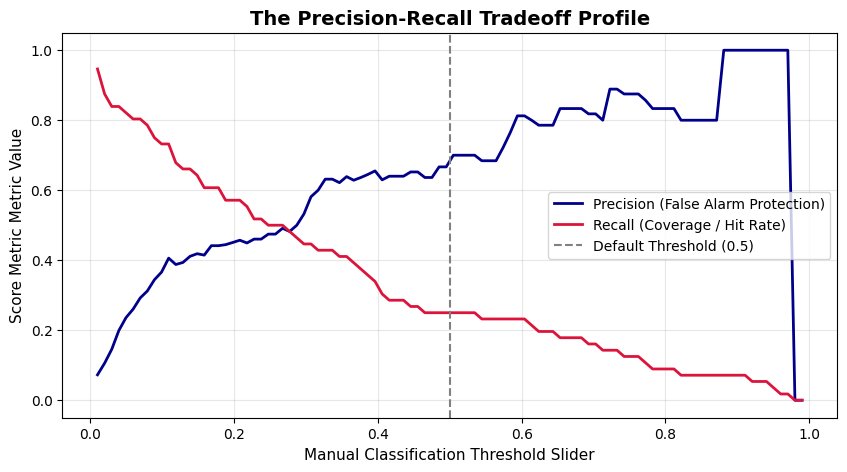

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# generate an imbalanced dataset
# 1000 transactions total: 950 Legitimate (0), 50 Fraudulent (1)
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2,
                           n_redundant=0, weights=[0.95, 0.05], random_state=42)
# the accuracy lie (the dummy model)
dummy_predictions = np.zeros_like(y) # Hardcoded to always predict 0

print("--- THE ACCURACY TRAP (DUMMY MODEL) ---")
print(f"Dummy Accuracy:  {accuracy_score(y, dummy_predictions):.4f} <-- Looks perfect!")
print(f"Dummy Precision: {precision_score(y, dummy_predictions, zero_division=0):.4f}")
print(f"Dummy Recall:    {recall_score(y, dummy_predictions):.4f}")
print(f"Dummy F1-Score:  {f1_score(y, dummy_predictions):.4f} <-- Exposes the truth.")

# visualization
model = LogisticRegression()
model.fit(X, y)

# Get raw predicted probabilities for Class 1
probabilities = model.predict_proba(X)[:, 1]

thresholds = np.linspace(0.01, 0.99, 100)
precisions = []
recalls = []

for t in thresholds:
    # Custom thresholding logic
    custom_preds = (probabilities >= t).astype(int)
    precisions.append(precision_score(y, custom_preds, zero_division=0))
    recalls.append(recall_score(y, custom_preds))

# Plot the Tradeoff profile
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions, label='Precision (False Alarm Protection)', color='darkblue', linewidth=2)
plt.plot(thresholds, recalls, label='Recall (Coverage / Hit Rate)', color='crimson', linewidth=2)
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default Threshold (0.5)')
plt.title('The Precision-Recall Tradeoff Profile', fontsize=14, fontweight='bold')
plt.xlabel('Manual Classification Threshold Slider', fontsize=11)
plt.ylabel('Score Metric Metric Value', fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Phase 4: Multi-Class Metrics (Scaling to 3+ Categories)
Up to this point, your model has only had to make a binary choice: Yes or No, Fraud or Safe. But what happens when you deploy a model to classify support tickets into three distinct departments: Tech Support, Billing, or Sales?

When you scale up to a Multi-Class problem, the basic concepts of True Positives, Precision, and Recall stay exactly the same—but we have to calculate them by treating every single category as its own individual island.

## 1. The Multi-Class Confusion Matrix
For a 3-class problem, your matrix scales up from a 2x2 grid to a 3x3 grid.

The Rows represent the Actual, real-world classes.
The Columns represent what your model predicted.

Let's look at a concrete example. Imagine we test a model on 18 customer emails:

| | Predicted Tech | Predicted Billing | Predicted Sales | Actual Total |
|---|---|---|---|---|
| Actual Tech | 6 | 1 | 1 | 8 |
| Actual Billing | 0 | 4 | 2 | 6 |
| Actual Sales | 1 | 0 | 3 | 4 |
| Predicted Total | 7 | 5 | 6 | Total N = 18 |

### Reading the Matrix Blueprint:
- **The Diagonal (6, 4, 3):** These are your absolute wins. These are the samples where the Actual matched the Prediction perfectly.
- **The Off-Diagonal Elements:** These are your specific misclassifications. For example, looking at Row 2, Column 3: there were 2 emails that were actually Billing, but your model accidentally sent them to Sales.

## 2. Calculating Multi-Class Precision and Recall
To find Precision and Recall for a 3x3 matrix, you must use the "One-vs-All" approach. You pick one single class to focus on, pretend it is the "Positive" class, and group all other classes together as the "Negative" class.

Let's calculate the metrics for Tech Support:

**Tech Precision:**
"Out of all the tickets my model claimed were Tech Support (Column Total), how many were actually correct?"

$$\text{Precision}_{\text{Tech}} = \frac{\text{True Hits in Tech Column}}{\text{Total Tech Column Sum}} = \frac{6}{6 + 0 + 1} = \frac{6}{7} = \mathbf{85.7\%}$$

**Tech Recall:**
"Out of all the actual Tech Support tickets in the real world (Row Total), how many did my model manage to catch?"

$$\text{Recall}_{\text{Tech}} = \frac{\text{True Hits in Tech Row}}{\text{Total Tech Row Sum}} = \frac{6}{6 + 1 + 1} = \frac{6}{8} = \mathbf{75.0\%}$$

You repeat this process to get an individual Precision, Recall, and F1-Score for every single category in your dataset.

## 3. Scaling Up: Macro vs. Micro vs. Weighted Averages
When your manager asks, "What is the overall F1-Score of our multi-class routing model?" you can't hand them three different numbers. You have to aggregate them into a single score. There are three distinct engineering methods to do this, and choosing the wrong one can completely mask model failures.

### Macro Average:
Calculate the metric independently for each class, and then take a simple arithmetic average.

$$\text{Macro F1} = \frac{\text{F1}_{\text{Tech}} + \text{F1}_{\text{Billing}} + \text{F1}_{\text{Sales}}}{3}$$

**The Catch:** It treats all classes as equally important, completely ignoring how many samples are in each class. If your model is perfect at Sales (which only gets 4 emails) but terrible at Tech (which gets millions), the Macro average will hide that failure.

### Weighted Average:
Calculate the metric for each class, but multiply each score by the number of actual samples (the "support") in that class before averaging.

**The Catch:** This is highly preferred for imbalanced datasets because it forces the final metric to care more about the categories that appear most frequently in the real world.

### Micro Average:
Collect all the True Positives, False Positives, and False Negatives across the entire system globally first, and then plug those grand totals into a single precision/recall formula.

**The Catch:** In pure multi-class classification where every sample gets exactly one label, Micro Precision, Micro Recall, and Overall Accuracy are mathematically identical.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


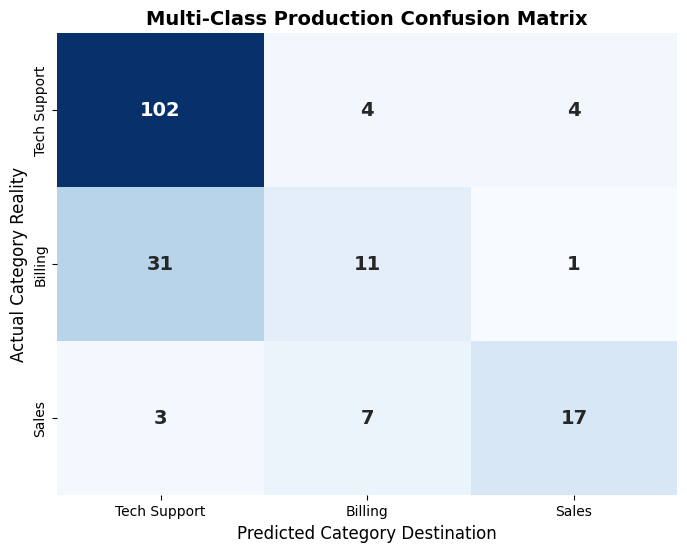


PRODUCTION CLASSIFICATION REPORT
              precision    recall  f1-score   support

Tech Support       0.75      0.93      0.83       110
     Billing       0.50      0.26      0.34        43
       Sales       0.77      0.63      0.69        27

    accuracy                           0.72       180
   macro avg       0.67      0.60      0.62       180
weighted avg       0.69      0.72      0.69       180



In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# 1. Generate a 3-class dataset
# three classes : 0-tech, 1-billing, 2-sales
X, y = make_classification(n_samples=600, n_features=5, n_informative=3,
                           n_redundant=0, n_repeated=0, n_classes=3, weights=[0.60, 0.25, 0.15], random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Multiclass logistic regression
model = LogisticRegression(multi_class='multinomial', solver='lbfgs')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 3. Visualize the 3X3 confusion matrix
cm = confusion_matrix(y_test, y_pred)
class_labels = ['Tech Support', 'Billing', 'Sales']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            cbar=False, annot_kws={"size": 14, "weight": "bold"})
plt.title('Multi-Class Production Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Category Destination', fontsize=12)
plt.ylabel('Actual Category Reality', fontsize=12)
plt.show()

# ==========================================
# STEP 4: GENERATE THE AGGREGATION REPORT
# ==========================================
print("\n========================================================")
print("PRODUCTION CLASSIFICATION REPORT")
print("========================================================")
print(classification_report(y_test, y_pred, target_names=class_labels))